# Peng–Robinson equation of state: physics, corresponding states, and mixtures

The [Peng–Robinson equation of state (PR EOS)](https://doi.org/10.1021/i160057a011) is a semi-empirical **cubic equation of state** introduced in 1976. It gives pressure from temperature, molar volume, and composition, while retaining a compact connection to intermolecular repulsion and attraction. For a pure fluid,

$$
P(T,V_m)=\frac{RT}{V_m-b}
-\frac{a(T)}{V_m(V_m+b)+b(V_m-b)}
=\frac{RT}{V_m-b}-\frac{a(T)}{V_m^2+2bV_m-b^2}.
$$

The two terms encode a useful physical picture:

- $RT/(V_m-b)$ is the repulsive contribution. The covolume $b$ represents excluded volume, so the pressure diverges as $V_m\rightarrow b^+$ and the model is evaluated only for $V_m>b$.
- The negative term is the cohesive contribution. The effective parameter $a(T)$ represents attractions, which lower the pressure relative to a purely repulsive fluid. At large $V_m$ it decays approximately as $V_m^{-2}$.

Thus PR approaches $P=RT/V_m$ in the dilute limit. The parameters are effective, macroscopic quantities rather than a literal molecular diameter and pair potential. The adjective *cubic* refers to the cubic polynomial in $V_m$ (or in $Z=PV_m/(RT)$) obtained at fixed $T$ and $P$; it does not refer to the number of fluid parameters. One real root occurs in much of the one-phase region, while three real roots can occur below the critical temperature.

ExoEOS implements the same model through the reduced residual molar Helmholtz energy. With $\rho=1/V_m$, $\delta=b\rho$, and $\alpha^r=A^r/(nRT)$,

$$
\alpha^r=-\ln(1-\delta)
-\frac{a(T)}{2\sqrt{2}bRT}
\ln\!\left[
\frac{1+(1+\sqrt{2})\delta}{1+(1-\sqrt{2})\delta}
\right],
\qquad
P=\rho RT\left[1+\rho
\left(\frac{\partial\alpha^r}{\partial\rho}\right)_T\right].
$$

This free-energy form makes pressure, chemical potentials, and fugacity coefficients thermodynamically consistent and accessible by automatic differentiation.

## A three-parameter corresponding-states model

In the original PR76 parameterization, the pure-fluid coefficients are

$$
a(T)=\Omega_a\frac{R^2T_c^2}{P_c}\alpha(T),
\qquad
b=\Omega_b\frac{RT_c}{P_c},
$$

$$
\alpha(T)=\left[1+\kappa(\omega)
\left(1-\sqrt{T/T_c}\right)\right]^2,
\qquad
\kappa(\omega)=0.37464+1.54226\omega-0.26992\omega^2,
$$

with $\Omega_a=0.45723552892138218938$ and $\Omega_b=0.077796073903888455972$. These are the exact critical-condition constants given by [Bell and Deiters (2021)](https://doi.org/10.1021/acs.iecr.1c00847). ExoEOS uses the original PR76 $\kappa$ correlation for every value of $\omega$.

The three pure-fluid inputs have distinct roles:

| Input | Meaning in corresponding states |
|---|---|
| Critical temperature $T_c$ | The temperature at the end of vapor–liquid coexistence; it sets the temperature scale. |
| Critical pressure $P_c$ | The pressure at that endpoint; together with $T_c$, it sets the molar-volume scale $RT_c/P_c$. |
| Acentric factor $\omega$ | An empirical measure of departure from the reduced vapor-pressure curve of a simple, nearly spherical fluid; PR uses it to shape the temperature dependence of attraction. |

The [Pitzer acentric factor](https://doi.org/10.1021/ja01618a002) is defined by

$$
\omega=-\log_{10}\left[
\left.\frac{P_{\mathrm{sat}}}{P_c}\right|_{T/T_c=0.7}
\right]-1.
$$

It summarizes effects of molecular shape, complexity, and polarity through a readily tabulated vapor-pressure property; it is not a direct microscopic measure of any one of them. For CO₂, $0.7T_c\simeq212.9$ K lies below the triple point, so this definition is understood through an extrapolated liquid vapor-pressure curve.

The corresponding-states structure becomes explicit on defining $T_r=T/T_c$, $P_r=P/P_c$, and $\widehat V=P_cV_m/(RT_c)$:

$$
P_r=\frac{T_r}{\widehat V-\Omega_b}
-\frac{\Omega_a\alpha(T_r,\omega)}
{\widehat V^2+2\Omega_b\widehat V-\Omega_b^2}.
$$

No fluid-specific quantity remains except $\omega$. This is why PR is a generalized EOS based on three-parameter corresponding states: the same reduced equation is reused for different pure fluids. Once $(T_c,P_c,\omega)$ and the PR76 convention are specified, the pure-fluid PR pressure surface is completely determined. The original paper calls PR a *two-constant* EOS because its pressure form contains the two structural coefficients $a$ and $b$; the corresponding-states construction nevertheless uses the three fluid properties $(T_c,P_c,\omega)$, with $\omega$ controlling $a(T)$.

The critical-point constraints

$$
\left(\frac{\partial P}{\partial V_m}\right)_{T_c}=0,
\qquad
\left(\frac{\partial^2 P}{\partial V_m^2}\right)_{T_c}=0
$$

fix $\Omega_a$ and $\Omega_b$. They also force the same critical compressibility for every PR fluid,

$$
Z_{c,\mathrm{PR}}=0.30740130869870385,
\qquad
V_{c,\mathrm{PR}}=Z_{c,\mathrm{PR}}\frac{RT_c}{P_c}.
$$

Consequently $V_c$ is a PR prediction, not a fourth input, and it need not equal the measured critical volume.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/exoeos_matplotlib")

from jax import config

config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from exoeos import PengRobinsonEOS, get_critical_properties, state_tp, state_trho
from exoeos.constants import MOLAR_GAS_CONSTANT

PR_OMEGA_B = 0.077796073903888455972
PR_CRITICAL_COMPRESSIBILITY = (1.0 - PR_OMEGA_B) / 3.0
CO2_REFERENCE_CRITICAL_DENSITY = 10_624.905587175583  # mol m^-3

co2 = get_critical_properties("CO2")
co2_eos = PengRobinsonEOS(
    critical_temperatures=jnp.asarray([co2.critical_temperature]),
    critical_pressures=jnp.asarray([co2.critical_pressure]),
    acentric_factors=jnp.asarray([co2.acentric_factor]),
)
co2_composition = jnp.asarray([1.0])

critical_volume_pr_l_mol = (
    PR_CRITICAL_COMPRESSIBILITY
    * MOLAR_GAS_CONSTANT
    * co2.critical_temperature
    / co2.critical_pressure
    * 1.0e3
)
critical_volume_reference_l_mol = 1.0e3 / CO2_REFERENCE_CRITICAL_DENSITY
covolume_l_mol = (
    PR_OMEGA_B
    * MOLAR_GAS_CONSTANT
    * co2.critical_temperature
    / co2.critical_pressure
    * 1.0e3
)
critical_pressure_mpa = co2.critical_pressure / 1.0e6

critical_state = state_trho(
    co2_eos,
    co2.critical_temperature,
    1.0e3 / critical_volume_pr_l_mol,
    co2_composition,
)
np.testing.assert_allclose(critical_state.P, co2.critical_pressure, rtol=2.0e-12)
np.testing.assert_allclose(
    critical_state.Z, PR_CRITICAL_COMPRESSIBILITY, rtol=2.0e-12
)

print(f"CO2 Tc                  = {co2.critical_temperature:.6f} K")
print(f"CO2 Pc                  = {critical_pressure_mpa:.6f} MPa")
print(f"CO2 omega               = {co2.acentric_factor:.5f}")
print(f"PR covolume b            = {covolume_l_mol:.6f} L mol^-1")
print(f"PR critical volume       = {critical_volume_pr_l_mol:.6f} L mol^-1")
print(
    f"Reference critical volume = {critical_volume_reference_l_mol:.6f} L mol^-1"
)

CO2 Tc                  = 304.128200 K
CO2 Pc                  = 7.377298 MPa
CO2 omega               = 0.22394
PR covolume b            = 0.026666 L mol^-1
PR critical volume       = 0.105366 L mol^-1
Reference critical volume = 0.094118 L mol^-1


## CO₂ pressure–volume isotherms

The CO₂ values above come from the [CoolProp fluid-information page](https://coolprop.org/fluid_properties/fluids/CarbonDioxide.html). Its reference critical molar density corresponds to $V_c=0.094118$ L mol$^{-1}$, whereas the unmodified PR EOS predicts $V_{c,\mathrm{PR}}=0.105366$ L mol$^{-1}$. The vertical dashed line in the following **PR diagram** therefore marks the model critical volume. This distinction exposes a common limitation of unmodified cubic equations: matching the input $T_c$ and $P_c$ does not guarantee an accurate liquid or critical volume.

We evaluate isotherms from 200 K to 360 K and insert the exact $T_c$ into the grid. PR is singular at $V_m=b$, so values are evaluated only for $V_m>b$ even though the displayed horizontal axis starts at zero. The limits are fixed to $0$–$0.5$ L mol$^{-1}$ and $-15$–$15$ MPa to make the critical region and the subcritical loops visible.

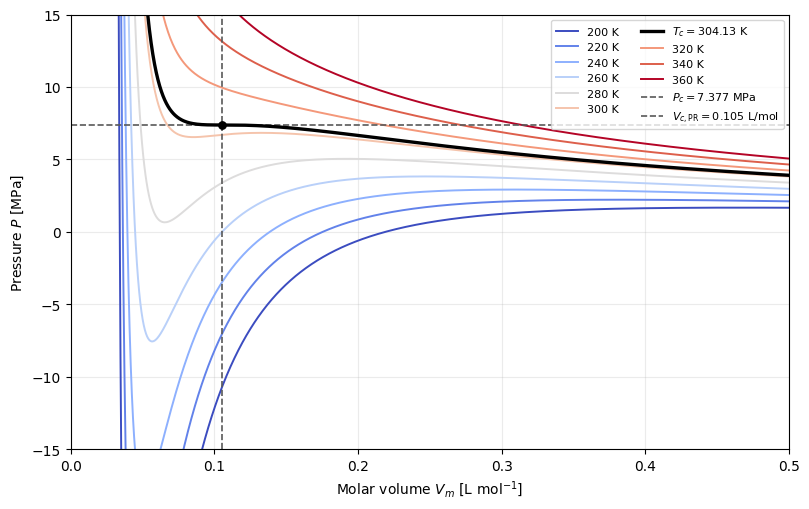

In [2]:
temperatures = np.sort(
    np.r_[np.arange(200.0, 361.0, 20.0), co2.critical_temperature]
)
volume_l_mol = np.linspace(1.001 * covolume_l_mol, 0.5, 1200)
molar_density = jnp.asarray(1.0e3 / volume_l_mol)

def pressure_isotherm(temperature):
    return jax.vmap(
        lambda density: state_trho(
            co2_eos, temperature, density, co2_composition
        ).P
    )(molar_density) / 1.0e6

pressure_mpa = np.asarray(
    jax.vmap(pressure_isotherm)(jnp.asarray(temperatures))
)

fig, ax = plt.subplots(figsize=(8.2, 5.2))
for temperature, pressure in zip(temperatures, pressure_mpa):
    is_critical = np.isclose(temperature, co2.critical_temperature)
    label = (
        rf"$T_c={temperature:.2f}$ K"
        if is_critical
        else f"{temperature:.0f} K"
    )
    color = (
        "black"
        if is_critical
        else plt.colormaps["coolwarm"]((temperature - 200.0) / 160.0)
    )
    ax.plot(
        volume_l_mol,
        pressure,
        color=color,
        linewidth=2.4 if is_critical else 1.4,
        label=label,
        zorder=3 if is_critical else 2,
    )

ax.axhline(
    critical_pressure_mpa,
    color="0.35",
    linestyle="--",
    linewidth=1.2,
    label=rf"$P_c={critical_pressure_mpa:.3f}$ MPa",
)
ax.axvline(
    critical_volume_pr_l_mol,
    color="0.35",
    linestyle="--",
    linewidth=1.2,
    label=rf"$V_{{c,\mathrm{{PR}}}}={critical_volume_pr_l_mol:.3f}$ L/mol",
)
ax.scatter(
    critical_volume_pr_l_mol,
    critical_pressure_mpa,
    color="black",
    s=28,
    zorder=4,
)
ax.set(
    xlim=(0.0, 0.5),
    ylim=(-15.0, 15.0),
    xlabel=r"Molar volume $V_m$ [L mol$^{-1}$]",
    ylabel=r"Pressure $P$ [MPa]",
)
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

### How to read the diagram

- At large $V_m$, every curve approaches the ideal-gas behavior $P\simeq RT/V_m$.
- Compression toward $b=0.026666$ L mol$^{-1}$ produces the steep repulsive wall.
- At $T=T_c$, the black isotherm has a stationary inflection at $(V_{c,\mathrm{PR}},P_c)$. Above $T_c$ the isotherms are monotonic in the displayed region.
- The loops and negative pressures below $T_c$ are the mathematical continuation of a homogeneous cubic EOS, not the stable equilibrium path. Pure-fluid vapor–liquid coexistence instead requires equal pressure and chemical potential (or fugacity) in the two phases; a Maxwell equal-area construction is an equivalent graphical condition.

The 200 K curve is also below the CO₂ triple-point temperature of 216.592 K. It is included to show the requested temperature range, but it is an extrapolation of the fluid EOS; stable real CO₂ includes a solid phase there.

## Mixtures: a classical one-fluid construction

For component $i$, PR first constructs $a_i(T)$ and $b_i$ from $(T_{c,i},P_{c,i},\omega_i)$ using the pure-fluid equations above. ExoEOS then applies the classical quadratic-attraction and linear-covolume mixing rules

$$
a_{ij}(T)=(1-k_{ij})\sqrt{a_i(T)a_j(T)},
$$

$$
a_{\mathrm{mix}}(T,\boldsymbol{x})
=\sum_i\sum_j x_i x_j a_{ij}(T),
\qquad
b_{\mathrm{mix}}(\boldsymbol{x})=\sum_i x_i b_i.
$$

Substituting $a_{\mathrm{mix}}$ and $b_{\mathrm{mix}}$ into the same PR pressure equation treats the mixture as one composition-dependent effective fluid. The geometric mean estimates unlike-pair attraction; the dimensionless binary interaction parameter $k_{ij}$ corrects that estimate. Conventionally $k_{ii}=0$ and $k_{ij}=k_{ji}$. ExoEOS uses a zero matrix when it is omitted.

A mixture therefore requires the mole fractions $\boldsymbol{x}$ in addition to each component's $(T_c,P_c,\omega)$, and predictive work may also require $k_{ij}$ values fitted to appropriate mixture data. Setting every $k_{ij}=0$ is an explicit modeling assumption, not a universal law.

In [3]:
species = ("CO2", "H2")
records = tuple(get_critical_properties(name) for name in species)
binary_interactions = jnp.zeros((2, 2))  # illustrative, not fitted
mixture_eos = PengRobinsonEOS(
    critical_temperatures=jnp.asarray(
        [record.critical_temperature for record in records]
    ),
    critical_pressures=jnp.asarray(
        [record.critical_pressure for record in records]
    ),
    acentric_factors=jnp.asarray(
        [record.acentric_factor for record in records]
    ),
    binary_interaction_parameters=binary_interactions,
)
mixture_composition = jnp.asarray([0.9, 0.1])
mixture_state = state_tp(
    mixture_eos,
    T=350.0,
    P=5.0e6,
    x=mixture_composition,
    phase="vapor",
)

print(f"Z = {float(mixture_state.Z):.6f}")
print(f"rho = {float(mixture_state.rho):.6f} mol m^-3")
print("ln(phi_i) =", np.asarray(mixture_state.lnphi))

Z = 0.863682
rho = 1989.363143 mol m^-3
ln(phi_i) = [-0.16593746  0.12789471]


## Scope and practical cautions

PR is popular because a small set of tabulated properties yields a pressure-explicit, computationally inexpensive, and thermodynamically complete residual model. That compactness also defines its limitations:

- $(T_c,P_c,\omega)$ determine the pure-fluid PVT and residual/departure behavior, but absolute enthalpy, entropy, and heat capacity still require an ideal-gas reference contribution.
- A requested `phase="vapor"` or `phase="liquid"` selects a cubic root; it does not by itself prove global phase stability or perform a saturation/flash calculation. A two-phase mixture generally has different liquid and vapor compositions, found by enforcing equality of every component fugacity.
- Unmodified PR can be inaccurate for liquid densities and for strongly polar, hydrogen-bonding, or associating fluids. Volume translations, improved alpha functions, calibrated binary interactions, or more detailed EOS families are used when those effects matter.

For equation details, see the [original PR76 paper](https://doi.org/10.1021/i160057a011) and the [NIST PR summary](https://trc.nist.gov/TDE/TDE_Help/DETAILS-TDE-Peng-Robinson-EOS.htm).